### **Support Vector Machines: Classifying Handwritten Digits**

#### Objective:
Your task is to build a **Support Vector Machine (SVM)** classifier to recognize handwritten digits from the famous **Digits dataset**. This homework will help you understand how SVM works for multi-class classification and how kernel tricks can improve performance.

---

#### Dataset:
Use the **Digits dataset** from `sklearn.datasets`. It contains 8x8 grayscale images of handwritten digits (0–9), represented as feature vectors.

---

#### Steps to Complete:

1. **Load the Dataset**
   - Import the `load_digits` dataset from `sklearn.datasets`.
   - Load the features (`data`) and labels (`target`).
   - Display the shape of the data and a few sample images using `matplotlib`.

2. **Data Exploration**
   - Explore the dataset:
     - How many samples and features are there?
     - What is the distribution of the target classes (0–9)?
   - Plot a few example digits with their corresponding labels.

3. **Data Splitting**
   - Split the dataset into training (80%) and test (20%) sets using `train_test_split` from `sklearn.model_selection`.
   - Standardize the feature values using `StandardScaler`.

4. **Build an SVM Classifier**
   - Train an SVM classifier using `SVC` from `sklearn.svm` with:
     - **Linear kernel**.
   - Evaluate the model on the test set using:
     - **Accuracy Score**.
     - **Confusion Matrix**.
     - **Classification Report** (precision, recall, F1-score).

5. **Experiment with Kernels**
   - Train and evaluate SVM classifiers with different kernels:
     - **Polynomial kernel** (`kernel='poly'`).
     - **Radial Basis Function (RBF) kernel** (`kernel='rbf'`).
   - Compare their performance (accuracy, F1-score, etc.).

6. **Hyperparameter Tuning**
   - Use `GridSearchCV` to find the best values for SVM hyperparameters, such as:
     - `C`: Regularization parameter.
     - `gamma`: Kernel coefficient for RBF.
     - `degree`: Polynomial kernel degree.
   - Report the best hyperparameters and the resulting model performance.

7. **Visualization**
   - Plot a confusion matrix for the best model.
   - Use `PCA` or `t-SNE` to reduce the dimensionality of the feature space to 2D or 3D and visualize the data distribution.

---

#### Bonus Challenges (Optional):

1. **Feature Importance**
   - Analyze the support vectors and discuss their role in defining the decision boundaries.

2. **Custom Kernel**
   - Implement a custom kernel function and train the SVM with it.

3. **Comparison with Other Models**
   - Compare the performance of SVM with another classifier, such as:
     - **Logistic Regression**.
     - **Random Forest**.

4. **Real-World Application**
   - Extend the task to a larger dataset, such as **MNIST** (available through `tensorflow` or `keras.datasets`), and train an SVM on a subset of the data (e.g., 5,000 samples).

---

#### Deliverables:
- A Python script or Jupyter Notebook containing:
  - Code for loading, exploring, and preprocessing the dataset.
  - Implementation of SVM with different kernels and hyperparameters.
  - Evaluation results and visualizations.
- A brief report discussing:
  - How well the SVM performed with different kernels.
  - The impact of hyperparameter tuning on model performance.
  - Observations about the dataset and the classification task.

---

#### Useful Hints:
- Use `seaborn` for advanced visualizations (e.g., heatmaps for confusion matrix).
- Remember to scale the data before training the SVM for better results.
- For hyperparameter tuning, set `verbose=2` in `GridSearchCV` to track the process.

---

### Key Learning Goals:
- Understand how SVM handles multi-class classification.
- Learn the impact of different kernels on SVM performance.
- Develop skills in hyperparameter tuning and result interpretation.
- Explore the role of support vectors and decision boundaries in SVM.

Data shape: (1797, 64)
Target shape: (1797,)


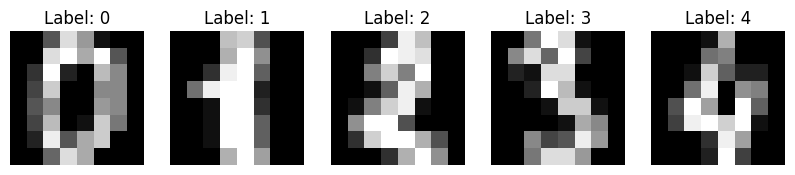

In [1]:
# =========================================
# Support Vector Machines: Handwritten Digits
# =========================================

# Load the Dataset
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

digits = load_digits()
X, y = digits.data, digits.target

print("Data shape:", X.shape)
print("Target shape:", y.shape)

# Show a few sample images
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.show()


Class distribution:
Digit 0: 178 samples
Digit 1: 182 samples
Digit 2: 177 samples
Digit 3: 183 samples
Digit 4: 181 samples
Digit 5: 182 samples
Digit 6: 181 samples
Digit 7: 179 samples
Digit 8: 174 samples
Digit 9: 180 samples


C:\Users\Mezon\AppData\Local\Temp\ipykernel_23016\3150158578.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="viridis")


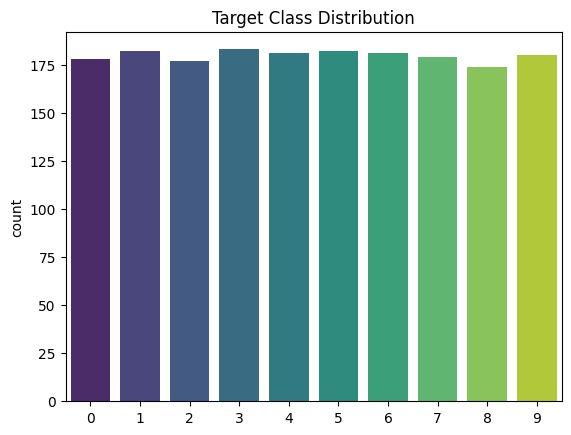

In [2]:
# Data Exploration
unique, counts = np.unique(y, return_counts=True)
print("Class distribution:")
for u, c in zip(unique, counts):
    print(f"Digit {u}: {c} samples")

# Visualize class distribution
sns.countplot(x=y, palette="viridis")
plt.title("Target Class Distribution")
plt.show()


In [3]:
# Data Splitting and Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Linear Kernel SVM Accuracy: 0.975

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.94      0.93        36
           2       1.00      1.00      1.00        35
           3       0.97      0.97      0.97        37
           4       1.00      1.00      1.00        36
           5       1.00      0.97      0.99        37
           6       1.00      1.00      1.00        36
           7       0.95      1.00      0.97        36
           8       0.97      0.89      0.93        35
           9       0.95      0.97      0.96        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360



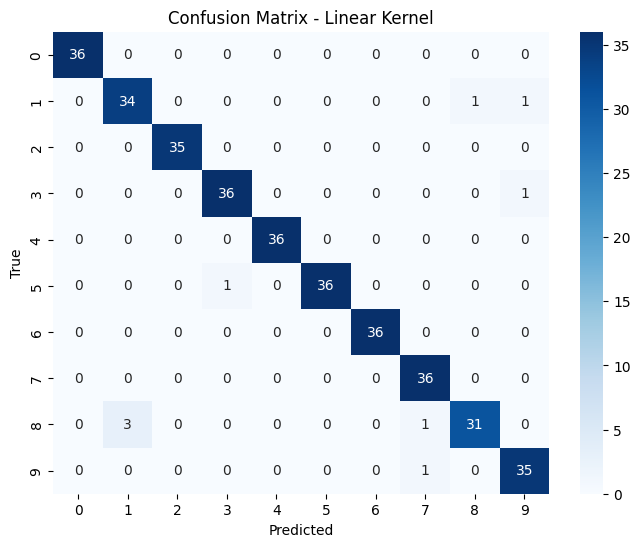

In [4]:
# Build an SVM Classifier (Linear Kernel)
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)

print("Linear Kernel SVM Accuracy:", accuracy_score(y_test, y_pred_linear))
print("\nClassification Report:\n", classification_report(y_test, y_pred_linear))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_linear)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Linear Kernel")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [5]:
# Step 5: Experiment with Kernels (Poly and RBF)
kernels = ['poly', 'rbf']
for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"\nKernel: {k}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))



Kernel: poly
Accuracy: 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.97      0.97      0.97        36
           2       1.00      0.97      0.99        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.94      0.97        36
           7       1.00      0.97      0.99        36
           8       0.81      0.97      0.88        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360


Kernel: rbf
Accuracy: 0.975
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      0.97      0.96        36
      

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'C': 10, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}
Best Score: 0.9874709639953542

Best Model Accuracy: 0.9944444444444445
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       1.00      1.00      1.00        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       1.00      1.00      1.00        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.97      1.00      0.99        36
           8       0.97      1.00      0.99        35
           9       1.00      0.97      0.99        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



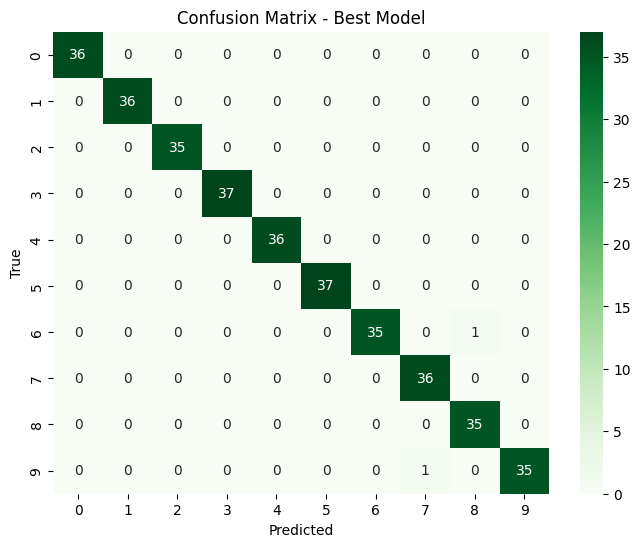

In [6]:
# Step 6: Hyperparameter Tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf', 'poly'],
    'degree': [2, 3, 4]
}

grid = GridSearchCV(SVC(), param_grid, cv=5, verbose=2, n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print("\nBest Model Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

# Confusion Matrix for Best Model
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8,6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
